# Cane Corso Regression and Testing — тестова проба

Идеята ми е да използвам темите от regression урока, но не със сухи абстрактни числа, а с пример, свързан с Cane Corso:

- възраст по месеци
- тегло
- височина при холката
- мъжко / женско куче
- сравнение със стандарт
- прогнозиране на растеж
- откриване на необичайни стойности
- тестване на модела


---

## Какво ще направя?

Ще мина през основните теми:

1. **Regression — problem statement and motivation**  
   Ще обясня защо regression може да е полезна при Cane Corso растеж и стандарт.

2. **Ordinary Least Squares**  
   Ще покажа как моделът намира най-добрата линия през данните.

3. **Simulated example**  
   Ще създам примерни данни за растеж на Cane Corso.

4. **Implementation on example data**  
   Ще приложа regression върху тези данни.

5. **RANSAC robust regression**  
   Ще добавя необичайни стойности и ще покажа как robust regression може да помогне.

6. **Polynomial regression**  
   Ще покажа защо растежът може да не е идеално права линия.

7. **Multi-dimensional linear regression**  
   Ще използвам повече от един вход, например възраст + височина + пол.

8. **Regularization**  
   Ще покажа как моделът може да се направи по-стабилен.

9. **Model testing**  
   Ще използвам MSE и basic tests, за да проверя дали резултатите имат логика.

---

## Финална идея

Целта ми е да направя  как regression може да се използва за Cane Corso анализ:

`данни → модел → прогноза → графика → грешка → тест`

Да бъде основа за бъдещ Cane Corso Growth / Standard Assistant.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Imports loaded successfully")

Imports loaded successfully


# 1. Regression — идея и мотивация

В тази част започвам с основната идея на regression.

Regression ми помага да намеря връзка между две неща.

В примера с Cane Corso мога да гледам:

`възраст → тегло`

Тоест искам да видя как приблизително се променя теглото, когато кучето расте по месеци.

Това не означава, че моделът знае всичко за кучето.  
Той просто търси математическа тенденция в данните.

Пример:

- ако кучето е на 3 месеца, очаквам по-ниско тегло
- ако кучето е на 8 месеца, очаквам по-високо тегло
- ако кучето е на 12 месеца, очаквам да е близо до възрастен диапазон

Целта ми е да използвам regression като помощен инструмент за анализ, графика и прогноза.

In [4]:
# Примерни данни за Cane Corso растеж


months = np.array([3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

male_weight = np.array([14, 19, 24, 29, 34, 39, 43, 46, 48, 50])
female_weight = np.array([12, 16, 21, 25, 30, 34, 38, 41, 43, 45])

growth_data = pd.DataFrame({
    "Месец": list(months) + list(months),
    "Пол": ["мъжко"] * len(months) + ["женско"] * len(months),
    "Тегло кг": list(male_weight) + list(female_weight)
})

growth_data

,Месец,Пол,Тегло кг
0,3,мъжко,14
1,4,мъжко,19
2,5,мъжко,24
3,6,мъжко,29
4,7,мъжко,34
5,8,мъжко,39
6,9,мъжко,43
7,10,мъжко,46
8,11,мъжко,48
9,12,мъжко,50


## 1.1 Какво показват данните?

Създадох примерна таблица с растеж по месеци.

Имам отделни примерни стойности за:

- мъжко Cane Corso
- женско Cane Corso

В тази първа част ще гледам само теглото.

Следващата цел е да начертая точките и да видя дали има ясна тенденция нагоре.

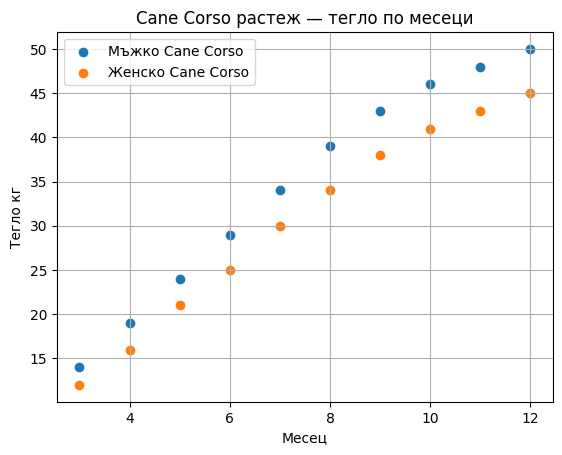

In [5]:
plt.scatter(months, male_weight, label="Мъжко Cane Corso")
plt.scatter(months, female_weight, label="Женско Cane Corso")

plt.title("Cane Corso растеж — тегло по месеци")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

## 1.2 Какво виждам от графиката?

От графиката виждам, че теглото се увеличава с месеците.

Това означава, че има положителна връзка между:

`месец` и `тегло`

Точно тук regression може да помогне.

Следващата стъпка е да намеря линия, която най-добре описва тази тенденция.

# 2. Ordinary Least Squares — намиране на най-добрата линия

В тази част правя първата regression линия.

Идеята е проста:

Имам точки на графиката и искам да намеря права линия, която минава възможно най-близо до тях.

Това се нарича **Ordinary Least Squares** или накратко **OLS**.

OLS се опитва да намали грешката между:

- реалното тегло
- теглото, което моделът предсказва

Моделът има форма:

`тегло = a * месец + b`

Където:

- `a` е наклонът на линията
- `b` е началната стойност

In [6]:
male_a, male_b = np.polyfit(months, male_weight, 1)

male_prediction = male_a * months + male_b

print("Мъжко Cane Corso regression формула:")
print(f"тегло = {male_a:.2f} * месец + {male_b:.2f}")

Мъжко Cane Corso regression формула:
тегло = 4.15 * месец + 3.51


In [7]:
female_a, female_b = np.polyfit(months, female_weight, 1)

female_prediction = female_a * months + female_b

print("Женско Cane Corso regression формула:")
print(f"тегло = {female_a:.2f} * месец + {female_b:.2f}")

Женско Cane Corso regression формула:
тегло = 3.81 * месец + 1.91


## 2.1 Какво означава формулата?

След като Python изчисли regression линията, получавам формула от типа:

`тегло = a * месец + b`

Ако `a` е положително число, това означава, че теглото расте с месеците.

Колкото по-голямо е `a`, толкова по-бързо се покачва теглото според модела.

Това е първата практическа полза от regression:  
мога да видя не само точките, а и общата тенденция.

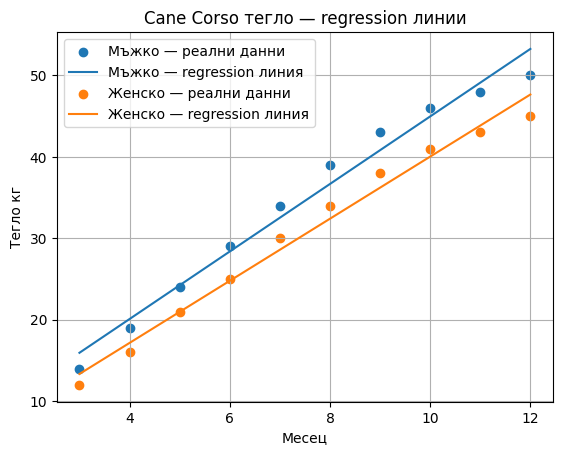

In [8]:
plt.scatter(months, male_weight, label="Мъжко — реални данни")
plt.plot(months, male_prediction, label="Мъжко — regression линия")

plt.scatter(months, female_weight, label="Женско — реални данни")
plt.plot(months, female_prediction, label="Женско — regression линия")

plt.title("Cane Corso тегло — regression линии")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

## 2.2 Какво показва графиката?

На графиката виждам реалните примерни точки и regression линиите.

Regression линията не е просто свързване на точките.

Тя е математическа линия, която се опитва да опише общата посока на растежа.

Това ми позволява да правя приблизителни прогнози за месец, който не е директно в таблицата.

In [9]:
month_to_predict = 8

predicted_male_weight = male_a * month_to_predict + male_b
predicted_female_weight = female_a * month_to_predict + female_b

print("Месец:", month_to_predict)

print("Прогнозно тегло за мъжко Cane Corso:", round(predicted_male_weight, 1), "кг")
print("Прогнозно тегло за женско Cane Corso:", round(predicted_female_weight, 1), "кг")

Месец: 8
Прогнозно тегло за мъжко Cane Corso: 36.7 кг
Прогнозно тегло за женско Cane Corso: 32.4 кг


## 2.3 Какво направих дотук?

Дотук направих първия реален regression пример.

Използвах примерни Cane Corso данни за тегло по месеци.

След това:

1. изчислих regression линия за мъжко куче
2. изчислих regression линия за женско куче
3. показах линиите на графика
4. направих прогноза за конкретен месец

Следващата стъпка е да измеря грешката на модела чрез MSE.

# 3. Model Testing — MSE

След като вече имам regression линии, трябва да проверя колко добре моделът пасва на данните.

За това използвам **MSE — Mean Squared Error**.

MSE сравнява:

- реалното тегло
- предвиденото тегло от regression модела

Колкото по-малко е MSE, толкова по-добре моделът пасва на данните.

Важно: MSE не казва дали кучето е добро или лошо.  
То само измерва математическата грешка на модела.

In [10]:
def mse(real_values, predicted_values):
    return np.mean((real_values - predicted_values) ** 2)

In [11]:
male_mse = mse(male_weight, male_prediction)
female_mse = mse(female_weight, female_prediction)

print("MSE за мъжко Cane Corso:", male_mse)
print("MSE за женско Cane Corso:", female_mse)

MSE за мъжко Cane Corso: 3.0654545454545485
MSE за женско Cane Corso: 1.9587878787878794


In [12]:
mse_results = pd.DataFrame({
    "Модел": [
        "Мъжко Cane Corso тегло",
        "Женско Cane Corso тегло"
    ],
    "Regression формула": [
        f"тегло = {male_a:.2f} * месец + {male_b:.2f}",
        f"тегло = {female_a:.2f} * месец + {female_b:.2f}"
    ],
    "MSE": [
        male_mse,
        female_mse
    ]
})

mse_results

,Модел,Regression формула,MSE
0,Мъжко Cane Corso тегло,тегло = 4.15 * месец + 3.51,3.065455
1,Женско Cane Corso тегло,тегло = 3.81 * месец + 1.91,1.958788


## 3.1 Какво означава MSE резултатът?

В тази таблица виждам грешката на regression модела за мъжко и женско Cane Corso.

Ако MSE е малко, значи линията описва данните добре.

Ако MSE е голямо, значи моделът не пасва добре и може би:

- данните са много разхвърляни
- има необичайни стойности
- линейна regression линия не е достатъчна
- трябва друг модел

Следващата стъпка е да добавя basic tests, за да проверя дали моделът има логика.

In [13]:
assert male_a > 0
assert female_a > 0

assert male_mse >= 0
assert female_mse >= 0

print("Tests passed")
print("Мъжкият regression модел има положителен наклон.")
print("Женският regression модел има положителен наклон.")
print("MSE стойностите са валидни.")

Tests passed
Мъжкият regression модел има положителен наклон.
Женският regression модел има положителен наклон.
MSE стойностите са валидни.


## 3.2 Какво тествах?

Тествах няколко основни неща:

1. Наклонът при мъжкото куче е положителен.
2. Наклонът при женското куче е положителен.
3. MSE стойностите не са отрицателни.

Това има логика, защото при растеж теглото трябва да се увеличава с месеците.

Ако някой от тези тестове падне, значи или данните са странни, или моделът не е подходящ.

# 4. Simulated Example with Noise

В тази част ще направя по-реалистичен пример.

Досега данните бяха много подредени.  
В реалния живот обаче теглото на кучето може да има малки отклонения заради:

- хранене
- активност
- генетика
- различен темп на растеж
- неточно измерване

Затова ще добавя случаен шум към данните.

Целта ми е да видя дали regression моделът пак може да намери общата тенденция.

In [14]:
np.random.seed(42)

noise_male = np.random.normal(loc=0, scale=2.0, size=len(months))
noise_female = np.random.normal(loc=0, scale=1.8, size=len(months))

male_weight_noisy = male_weight + noise_male
female_weight_noisy = female_weight + noise_female

noisy_growth_data = pd.DataFrame({
    "Month": list(months) + list(months),
    "Sex": ["male"] * len(months) + ["female"] * len(months),
    "Weight kg": list(male_weight_noisy) + list(female_weight_noisy)
})

noisy_growth_data

,Month,Sex,Weight kg
0,3,male,14.993428
1,4,male,18.723471
2,5,male,25.295377
3,6,male,32.046060
4,7,male,33.531693
5,8,male,38.531726
6,9,male,46.158426
7,10,male,47.534869
8,11,male,47.061051
9,12,male,51.085120


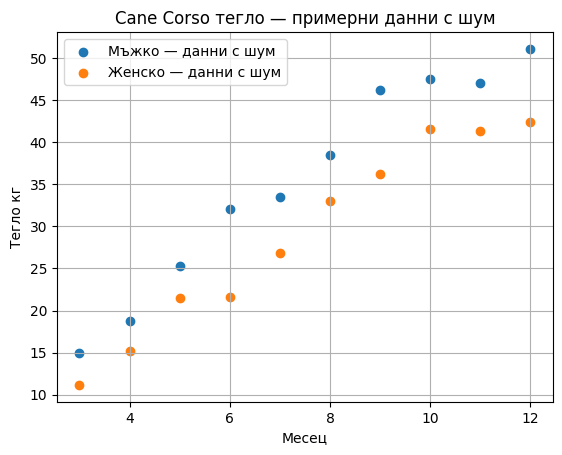

In [15]:
plt.scatter(months, male_weight_noisy, label="Мъжко — данни с шум")
plt.scatter(months, female_weight_noisy, label="Женско — данни с шум")

plt.title("Cane Corso тегло — примерни данни с шум")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

## 4.1 Какво виждам?

Сега точките вече не са идеално подредени.

Това е по-близо до реална ситуация, защото кучетата не растат напълно еднакво всеки месец.

Въпреки това пак виждам обща посока нагоре.

Следващата стъпка е да направя regression линия върху тези шумни данни.

In [16]:
male_noisy_a, male_noisy_b = np.polyfit(months, male_weight_noisy, 1)
female_noisy_a, female_noisy_b = np.polyfit(months, female_weight_noisy, 1)

male_noisy_prediction = male_noisy_a * months + male_noisy_b
female_noisy_prediction = female_noisy_a * months + female_noisy_b

print("Мъжко Cane Corso noisy regression формула:")
print(f"тегло = {male_noisy_a:.2f} * месец + {male_noisy_b:.2f}")

print()

print("Женско Cane Corso noisy regression формула:")
print(f"тегло = {female_noisy_a:.2f} * месец + {female_noisy_b:.2f}")

Мъжко Cane Corso noisy regression формула:
тегло = 4.13 * месец + 4.51

Женско Cane Corso noisy regression формула:
тегло = 3.73 * месец + 1.09


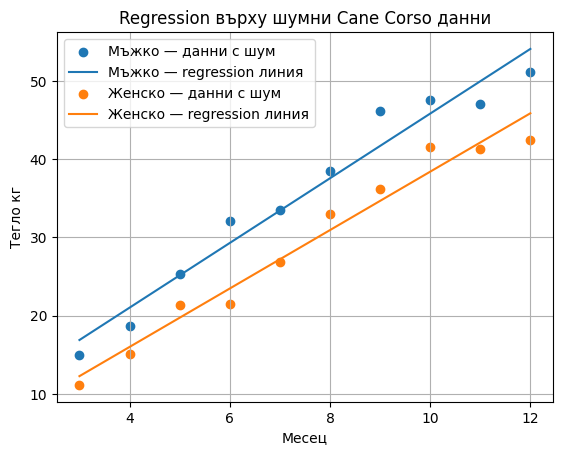

In [17]:
plt.scatter(months, male_weight_noisy, label="Мъжко — данни с шум")
plt.plot(months, male_noisy_prediction, label="Мъжко — regression линия")

plt.scatter(months, female_weight_noisy, label="Женско — данни с шум")
plt.plot(months, female_noisy_prediction, label="Женско — regression линия")

plt.title("Regression върху шумни Cane Corso данни")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

In [18]:
male_noisy_mse = mse(male_weight_noisy, male_noisy_prediction)
female_noisy_mse = mse(female_weight_noisy, female_noisy_prediction)

noisy_mse_results = pd.DataFrame({
    "Model": [
        "Male Cane Corso noisy weight",
        "Female Cane Corso noisy weight"
    ],
    "Regression formula": [
        f"weight = {male_noisy_a:.2f} * month + {male_noisy_b:.2f}",
        f"weight = {female_noisy_a:.2f} * month + {female_noisy_b:.2f}"
    ],
    "MSE": [
        male_noisy_mse,
        female_noisy_mse
    ]
})

noisy_mse_results

,Model,Regression formula,MSE
0,Male Cane Corso noisy weight,weight = 4.13 * month + 4.51,5.777341
1,Female Cane Corso noisy weight,weight = 3.73 * month + 1.09,3.728668


## 4.2 Какво направих в тази част?

В тази част добавих шум към примерните Cane Corso данни.

Това направи примера по-реалистичен.

След това:

1. създадох шумни данни
2. начертах ги на графика
3. направих regression линия върху тях
4. изчислих MSE
5. проверих дали моделът пак намира общата тенденция

Това показва, че regression може да работи и когато данните не са идеални.

In [19]:
assert male_noisy_a > 0
assert female_noisy_a > 0

assert male_noisy_mse >= 0
assert female_noisy_mse >= 0

print("Tests passed")
print("Noisy regression моделите имат положителен наклон.")
print("MSE стойностите са валидни.")

Tests passed
Noisy regression моделите имат положителен наклон.
MSE стойностите са валидни.


# 5. RANSAC / Robust Regression — работа с необичайни стойности

В тази част ще добавя outliers — стойности, които са много различни от нормалната тенденция.

Пример:

- грешно въведено тегло
- много едро куче
- неточно измерване
- случайна грешка в таблицата

Обикновената linear regression може да се изкриви от такива стойности.

Затова ще направя проста RANSAC-style логика, която търси линия, която пасва на повечето нормални точки, а не на всички точки на всяка цена.

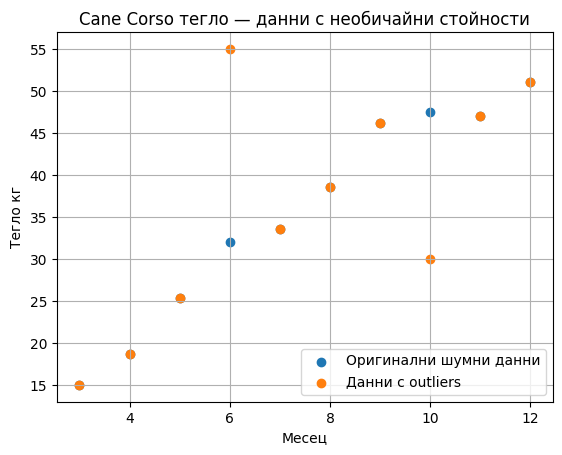

In [20]:
# Create outlier data based on male noisy weight

male_weight_outliers = male_weight_noisy.copy()

# Add unrealistic / unusual values
male_weight_outliers[3] = 55   # month 6 - too heavy
male_weight_outliers[7] = 30   # month 10 - too light

plt.scatter(months, male_weight_noisy, label="Оригинални шумни данни")
plt.scatter(months, male_weight_outliers, label="Данни с outliers")

plt.title("Cane Corso тегло — данни с необичайни стойности")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

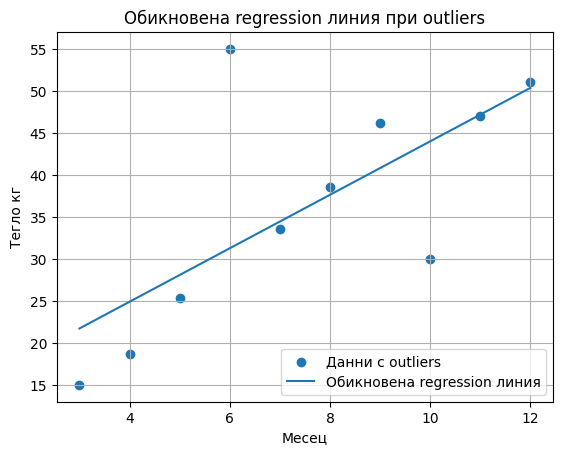

Обикновена regression формула:
тегло = 3.18 * месец + 12.17


In [21]:
ordinary_outlier_a, ordinary_outlier_b = np.polyfit(months, male_weight_outliers, 1)
ordinary_outlier_prediction = ordinary_outlier_a * months + ordinary_outlier_b

plt.scatter(months, male_weight_outliers, label="Данни с outliers")
plt.plot(months, ordinary_outlier_prediction, label="Обикновена regression линия")

plt.title("Обикновена regression линия при outliers")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

print("Обикновена regression формула:")
print(f"тегло = {ordinary_outlier_a:.2f} * месец + {ordinary_outlier_b:.2f}")

## 5.1 Какъв е проблемът?

Обикновената regression линия се опитва да пасне на всички точки.

Ако има няколко много странни стойности, линията може да се изкриви.

Това е проблем, защото една грешна стойност може да повлияе на цялата прогноза.

Затова използвам RANSAC-style подход:

1. пробвам много различни линии
2. проверявам колко точки са близо до всяка линия
3. избирам линията, която има най-много нормални точки около себе си

In [22]:
def simple_ransac_line(x_values, y_values, iterations=200, threshold=4):
    best_a = None
    best_b = None
    best_inliers = None
    best_inlier_count = 0

    x_values = np.array(x_values)
    y_values = np.array(y_values)

    for _ in range(iterations):
        sample_indices = np.random.choice(len(x_values), size=2, replace=False)

        x_sample = x_values[sample_indices]
        y_sample = y_values[sample_indices]

        a, b = np.polyfit(x_sample, y_sample, 1)
        prediction = a * x_values + b

        errors = np.abs(y_values - prediction)
        inliers = errors < threshold
        inlier_count = np.sum(inliers)

        if inlier_count > best_inlier_count:
            best_a = a
            best_b = b
            best_inliers = inliers
            best_inlier_count = inlier_count

    return best_a, best_b, best_inliers


ransac_a, ransac_b, inliers = simple_ransac_line(
    months,
    male_weight_outliers,
    iterations=500,
    threshold=4
)

ransac_prediction = ransac_a * months + ransac_b

print("RANSAC-style regression формула:")
print(f"тегло = {ransac_a:.2f} * месец + {ransac_b:.2f}")

print("Брой нормални точки:", np.sum(inliers))
print("Брой outliers:", len(inliers) - np.sum(inliers))

RANSAC-style regression формула:
тегло = 4.05 * месец + 2.53
Брой нормални точки: 7
Брой outliers: 3


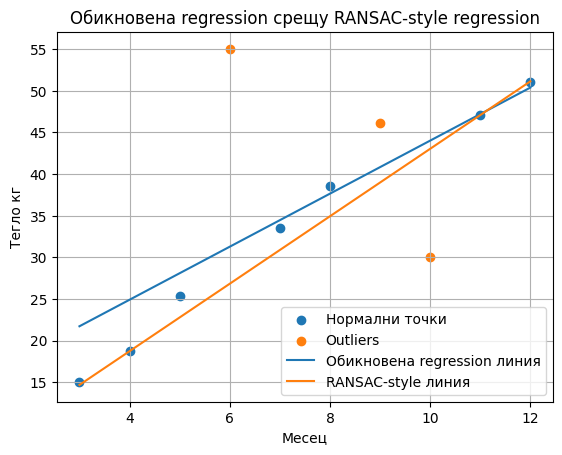

In [23]:
plt.scatter(
    months[inliers],
    male_weight_outliers[inliers],
    label="Нормални точки"
)

plt.scatter(
    months[~inliers],
    male_weight_outliers[~inliers],
    label="Outliers"
)

plt.plot(
    months,
    ordinary_outlier_prediction,
    label="Обикновена regression линия"
)

plt.plot(
    months,
    ransac_prediction,
    label="RANSAC-style линия"
)

plt.title("Обикновена regression срещу RANSAC-style regression")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

In [24]:
ordinary_outlier_mse = mse(male_weight_outliers, ordinary_outlier_prediction)
ransac_inlier_mse = mse(
    male_weight_outliers[inliers],
    ransac_prediction[inliers]
)

ransac_results = pd.DataFrame({
    "Модел": [
        "Обикновена regression с outliers",
        "RANSAC-style regression върху нормални точки"
    ],
    "Формула": [
        f"тегло = {ordinary_outlier_a:.2f} * месец + {ordinary_outlier_b:.2f}",
        f"тегло = {ransac_a:.2f} * месец + {ransac_b:.2f}"
    ],
    "MSE": [
        ordinary_outlier_mse,
        ransac_inlier_mse
    ]
})

ransac_results

,Модел,Формула,MSE
0,Обикновена regression с outliers,тегло = 3.18 * месец + 12.17,88.111102
1,RANSAC-style regression върху нормални точки,тегло = 4.05 * месец + 2.53,3.805146


## 5.2 Какво направих с RANSAC-style regression?

В тази част добавих необичайни стойности към данните.

След това сравних:

- обикновена regression линия
- RANSAC-style линия

Обикновената regression линия се влияе от всички точки, включително и от грешните или необичайните.

RANSAC-style подходът се опитва да намери линията, която пасва на повечето нормални точки, и отделя outliers.

Това може да е полезно при Cane Corso данни, защото понякога може да има:

- грешно въведено тегло
- неточно измерване
- куче с много различен растеж
- стойност, която трябва да се провери допълнително

In [25]:
assert ransac_a > 0
assert ordinary_outlier_mse >= 0
assert ransac_inlier_mse >= 0
assert np.sum(inliers) > 0

print("Tests passed")
print("RANSAC-style моделът има положителен наклон.")
print("Има открити нормални точки.")
print("MSE стойностите са валидни.")

Tests passed
RANSAC-style моделът има положителен наклон.
Има открити нормални точки.
MSE стойностите са валидни.


# 6. Polynomial Regression — когато растежът не е идеално права линия

В тази част ще пробвам polynomial regression.

Досега използвах linear regression:

`тегло = a * месец + b`

Това е права линия.

Но при Cane Corso растежът може да не е напълно линеен.  
В началото кучето може да расте по-бързо, а след това растежът да се забавя.

Затова ще пробвам модел от втора степен:

`тегло = a * месец² + b * месец + c`

Това вече е крива линия.

In [26]:
# Polynomial regression от 2-ра степен за мъжко Cane Corso

male_poly_coefficients = np.polyfit(months, male_weight_noisy, 2)

male_poly_prediction = np.polyval(male_poly_coefficients, months)

print("Polynomial coefficients:")
print(male_poly_coefficients)

print()
print("Формула:")
print(
    f"тегло = {male_poly_coefficients[0]:.2f} * месец² "
    f"+ {male_poly_coefficients[1]:.2f} * месец "
    f"+ {male_poly_coefficients[2]:.2f}"
)

Polynomial coefficients:
[-0.25627668  7.97580405 -7.79256207]

Формула:
тегло = -0.26 * месец² + 7.98 * месец + -7.79


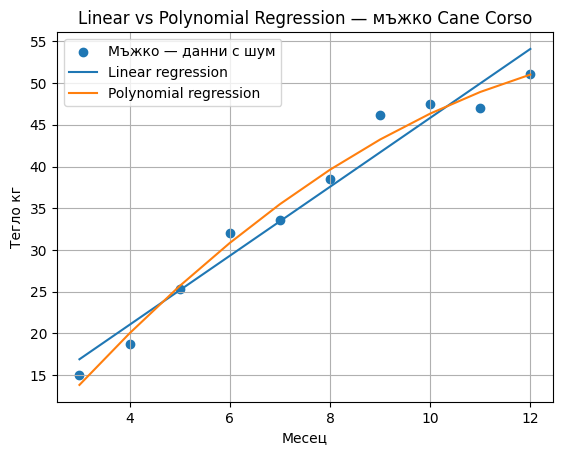

In [27]:
plt.scatter(months, male_weight_noisy, label="Мъжко — данни с шум")

plt.plot(months, male_noisy_prediction, label="Linear regression")
plt.plot(months, male_poly_prediction, label="Polynomial regression")

plt.title("Linear vs Polynomial Regression — мъжко Cane Corso")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

In [28]:
male_linear_mse = mse(male_weight_noisy, male_noisy_prediction)
male_poly_mse = mse(male_weight_noisy, male_poly_prediction)

poly_results = pd.DataFrame({
    "Модел": [
        "Linear regression",
        "Polynomial regression degree 2"
    ],
    "MSE": [
        male_linear_mse,
        male_poly_mse
    ]
})

poly_results

,Модел,MSE
0,Linear regression,5.777341
1,Polynomial regression degree 2,2.309556


## 6.1 Какво показва Polynomial Regression?

Тук сравних права линия и крива линия.

Linear regression търси една права тенденция.

Polynomial regression позволява на линията да се огъне.

Това може да е полезно при растеж, защото теглото не винаги се увеличава с една и съща скорост всеки месец.

Важно: ако използвам прекалено сложна крива, моделът може да започне да се нагажда прекалено много към данните.  
Това се нарича overfitting.

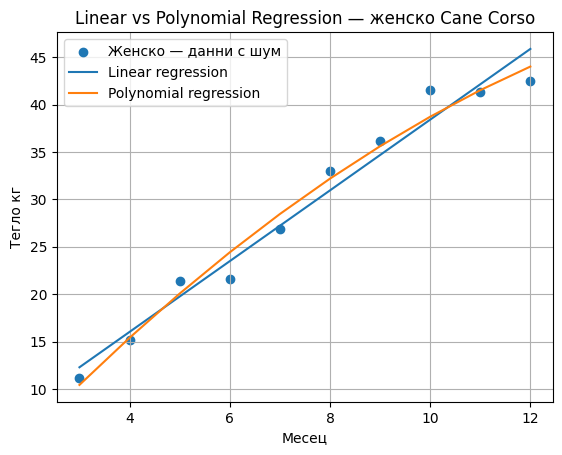

,Модел,MSE
0,Linear regression,3.728668
1,Polynomial regression degree 2,2.459180


In [29]:
# Polynomial regression от 2-ра степен за женско Cane Corso

female_poly_coefficients = np.polyfit(months, female_weight_noisy, 2)

female_poly_prediction = np.polyval(female_poly_coefficients, months)

plt.scatter(months, female_weight_noisy, label="Женско — данни с шум")

plt.plot(months, female_noisy_prediction, label="Linear regression")
plt.plot(months, female_poly_prediction, label="Polynomial regression")

plt.title("Linear vs Polynomial Regression — женско Cane Corso")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

female_linear_mse = mse(female_weight_noisy, female_noisy_prediction)
female_poly_mse = mse(female_weight_noisy, female_poly_prediction)

female_poly_results = pd.DataFrame({
    "Модел": [
        "Linear regression",
        "Polynomial regression degree 2"
    ],
    "MSE": [
        female_linear_mse,
        female_poly_mse
    ]
})

female_poly_results

In [30]:
assert male_poly_mse >= 0
assert female_poly_mse >= 0

assert len(male_poly_prediction) == len(months)
assert len(female_poly_prediction) == len(months)

print("Tests passed")
print("Polynomial regression predictions са създадени правилно.")
print("MSE стойностите са валидни.")

Tests passed
Polynomial regression predictions са създадени правилно.
MSE стойностите са валидни.


# 7. Multi-dimensional Linear Regression

В тази част правя regression модел с повече от един вход.

Досега използвах само:

`месец → тегло`

Сега ще използвам:

`месец + височина + пол → тегло`

Идеята ми е да проверя дали моделът може да прогнозира тегло по-добре, когато знае повече информация за кучето.

Това вече е multi-dimensional regression, защото входът не е само една стойност, а няколко характеристики.

In [31]:
# Примерни данни за multi-dimensional regression

multi_data = pd.DataFrame({
    "Месец": list(months) + list(months),
    "Пол": ["мъжко"] * len(months) + ["женско"] * len(months),
    "Височина см": [
        46, 53, 58, 62, 65, 66, 67, 68, 68, 68,
        44, 50, 55, 58, 60, 62, 63, 64, 64, 64
    ],
    "Тегло кг": list(male_weight_noisy) + list(female_weight_noisy)
})

multi_data

,Месец,Пол,Височина см,Тегло кг
0,3,мъжко,46,14.993428
1,4,мъжко,53,18.723471
2,5,мъжко,58,25.295377
3,6,мъжко,62,32.046060
4,7,мъжко,65,33.531693
5,8,мъжко,66,38.531726
6,9,мъжко,67,46.158426
7,10,мъжко,68,47.534869
8,11,мъжко,68,47.061051
9,12,мъжко,68,51.085120


## 7.1 Подготовка на данните

За да използвам пола в математически модел, трябва да го превърна в число.

Ще използвам:

- `мъжко = 1`
- `женско = 0`

Така моделът ще може да използва пола като входна характеристика.

In [32]:
multi_data["Пол код"] = multi_data["Пол"].map({
    "мъжко": 1,
    "женско": 0
})

multi_data

,Месец,Пол,Височина см,Тегло кг,Пол код
0,3,мъжко,46,14.993428,1
1,4,мъжко,53,18.723471,1
2,5,мъжко,58,25.295377,1
3,6,мъжко,62,32.046060,1
4,7,мъжко,65,33.531693,1
5,8,мъжко,66,38.531726,1
6,9,мъжко,67,46.158426,1
7,10,мъжко,68,47.534869,1
8,11,мъжко,68,47.061051,1
9,12,мъжко,68,51.085120,1


In [33]:
# X са входните данни
# y е това, което искам да предвидя

X = multi_data[["Месец", "Височина см", "Пол код"]].values
y = multi_data["Тегло кг"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20, 3)
y shape: (20,)


## 7.2 Формата на модела

Моделът ще има тази идея:

`тегло = a1 * месец + a2 * височина + a3 * пол + b`

Където:

- `a1` показва влиянието на месеца
- `a2` показва влиянието на височината
- `a3` показва влиянието на пола
- `b` е началната стойност

Това е като linear regression, но с повече входове.

In [34]:
# Добавям колона с единици за intercept b

X_with_intercept = np.column_stack([
    X,
    np.ones(len(X))
])

X_with_intercept[:5]

array([[ 3., 46.,  1.,  1.],
       [ 4., 53.,  1.,  1.],
       [ 5., 58.,  1.,  1.],
       [ 6., 62.,  1.,  1.],
       [ 7., 65.,  1.,  1.]])

In [35]:
# Решавам уравнението чрез least squares
# Това е multi-dimensional версия на Ordinary Least Squares

coefficients, residuals, rank, singular_values = np.linalg.lstsq(
    X_with_intercept,
    y,
    rcond=None
)

month_coef = coefficients[0]
height_coef = coefficients[1]
sex_coef = coefficients[2]
intercept = coefficients[3]

print("Multi-dimensional regression formula:")
print(
    f"тегло = {month_coef:.2f} * месец "
    f"+ {height_coef:.2f} * височина "
    f"+ {sex_coef:.2f} * пол "
    f"+ {intercept:.2f}"
)

Multi-dimensional regression formula:
тегло = 2.90 * месец + 0.48 * височина + 4.64 * пол + -20.73


In [36]:
multi_prediction = X_with_intercept @ coefficients

multi_data["Прогнозно тегло кг"] = multi_prediction
multi_data["Разлика кг"] = multi_data["Тегло кг"] - multi_data["Прогнозно тегло кг"]

multi_data

,Месец,Пол,Височина см,Тегло кг,Пол код,Прогнозно тегло кг,Разлика кг
0,3,мъжко,46,14.993428,1,14.713249,0.280179
1,4,мъжко,53,18.723471,1,20.976462,-2.252991
2,5,мъжко,58,25.295377,1,26.278431,-0.983054
3,6,мъжко,62,32.046060,1,31.099776,0.946283
4,7,мъжко,65,33.531693,1,35.440500,-1.908806
5,8,мъжко,66,38.531726,1,38.819978,-0.288252
6,9,мъжко,67,46.158426,1,42.199456,3.958970
7,10,мъжко,68,47.534869,1,45.578934,1.955935
8,11,мъжко,68,47.061051,1,48.477790,-1.416739
9,12,мъжко,68,51.085120,1,51.376646,-0.291526


In [37]:
multi_mse = mse(y, multi_prediction)

print("Multi-dimensional regression MSE:", multi_mse)

Multi-dimensional regression MSE: 3.124044303334954


In [38]:
simple_all_a, simple_all_b = np.polyfit(multi_data["Месец"], multi_data["Тегло кг"], 1)
simple_all_prediction = simple_all_a * multi_data["Месец"] + simple_all_b

simple_all_mse = mse(multi_data["Тегло кг"], simple_all_prediction)

model_comparison = pd.DataFrame({
    "Модел": [
        "Simple linear regression: месец → тегло",
        "Multi-dimensional regression: месец + височина + пол → тегло"
    ],
    "MSE": [
        simple_all_mse,
        multi_mse
    ]
})

model_comparison

,Модел,MSE
0,Simple linear regression: месец → тегло,15.385500
1,Multi-dimensional regression: месец + височина...,3.124044


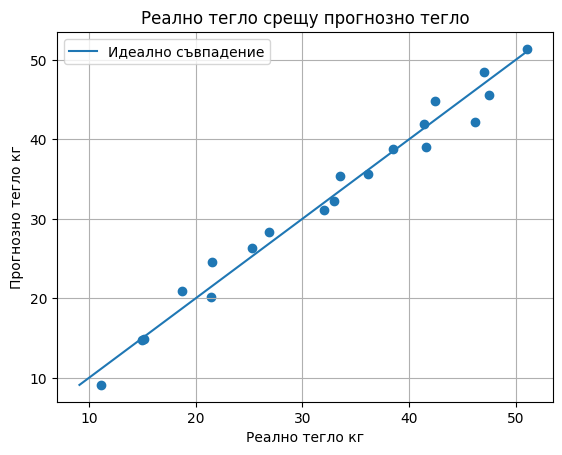

In [39]:
plt.scatter(multi_data["Тегло кг"], multi_data["Прогнозно тегло кг"])

min_value = min(multi_data["Тегло кг"].min(), multi_data["Прогнозно тегло кг"].min())
max_value = max(multi_data["Тегло кг"].max(), multi_data["Прогнозно тегло кг"].max())

plt.plot([min_value, max_value], [min_value, max_value], label="Идеално съвпадение")

plt.title("Реално тегло срещу прогнозно тегло")
plt.xlabel("Реално тегло кг")
plt.ylabel("Прогнозно тегло кг")
plt.grid(True)
plt.legend()

plt.show()

## 7.3 Какво показва тази графика?

На тази графика сравнявам реалното тегло с прогнозното тегло.

Ако точките са близо до линията, моделът прогнозира добре.

Ако точките са далеч от линията, моделът греши повече.

Тук вече използвам повече информация:

- месец
- височина
- пол

Затова моделът може да бъде по-полезен от простата regression линия, която гледа само месец.

In [40]:
# Пример: ново мъжко Cane Corso на 8 месеца, височина 66 см

нов_месец = 8
нова_височина = 66
нов_пол_код = 1  # мъжко

new_dog = np.array([
    нов_месец,
    нова_височина,
    нов_пол_код,
    1  # intercept
])

predicted_new_dog_weight = new_dog @ coefficients

print("Прогноза за ново куче:")
print("Месец:", нов_месец)
print("Височина:", нова_височина, "см")
print("Пол: мъжко")
print("Прогнозно тегло:", round(predicted_new_dog_weight, 1), "кг")

Прогноза за ново куче:
Месец: 8
Височина: 66 см
Пол: мъжко
Прогнозно тегло: 38.8 кг


In [41]:
assert multi_mse >= 0
assert len(multi_prediction) == len(y)
assert month_coef != 0
assert height_coef != 0

print("Tests passed")
print("Multi-dimensional regression моделът работи.")
print("Прогнозите са създадени правилно.")
print("MSE стойността е валидна.")

Tests passed
Multi-dimensional regression моделът работи.
Прогнозите са създадени правилно.
MSE стойността е валидна.


## 7.4 Какво направих в тази част?

В тази част направих multi-dimensional linear regression.

Вместо да използвам само месец, използвах няколко входни характеристики:

`месец + височина + пол`

Целта ми беше да направя модел, който прогнозира тегло по по-богата информация.

Това е по-близо до реален Cane Corso анализ, защото теглото не зависи само от възрастта.

То може да зависи и от:

- пол
- височина
- структура
- линия
- генетика
- хранене
- активност

В този notebook използвах само част от тези фактори, за да покажа beginner-friendly пример.

# 8. Regularization — по-стабилен regression модел

В тази част добавям regularization.

Досега направих multi-dimensional regression с:

`месец + височина + пол → тегло`

Когато моделът използва повече характеристики, има риск да се нагоди прекалено много към конкретните примерни данни.

Regularization помага моделът да бъде по-стабилен, като ограничава прекалено големите коефициенти.

Тук ще използвам Ridge-style regularization.

Идеята ми е да сравня:

- обикновена multi-dimensional regression
- regularized regression

In [42]:
# Standardization на входните данни
# Това помага regularization да работи по-справедливо,
# защото месец, височина и пол са в различни мащаби.

X_features = multi_data[["Месец", "Височина см", "Пол код"]].values
y_values = multi_data["Тегло кг"].values

X_mean = X_features.mean(axis=0)
X_std = X_features.std(axis=0)

X_scaled = (X_features - X_mean) / X_std

X_scaled_with_intercept = np.column_stack([
    X_scaled,
    np.ones(len(X_scaled))
])

print("Scaled X shape:", X_scaled_with_intercept.shape)

Scaled X shape: (20, 4)


In [43]:
def ridge_regression(X, y, alpha):
    """
    Ridge-style regression.
    alpha контролира силата на regularization.
    По-голям alpha = по-ограничен модел.
    """

    identity = np.eye(X.shape[1])

    # Не наказвам intercept колоната
    identity[-1, -1] = 0

    coefficients = np.linalg.inv(X.T @ X + alpha * identity) @ X.T @ y

    return coefficients

In [44]:
alpha = 1.0

ridge_coefficients = ridge_regression(
    X_scaled_with_intercept,
    y_values,
    alpha
)

ridge_prediction = X_scaled_with_intercept @ ridge_coefficients
ridge_mse = mse(y_values, ridge_prediction)

print("Ridge coefficients:")
print(ridge_coefficients)

print()
print("Ridge MSE:", ridge_mse)

Ridge coefficients:
[ 7.27225071  4.18915719  2.01286606 32.2864687 ]

Ridge MSE: 3.3725865845114713


In [45]:
regularization_comparison = pd.DataFrame({
    "Модел": [
        "Обикновена multi-dimensional regression",
        "Ridge-style regularized regression"
    ],
    "MSE": [
        multi_mse,
        ridge_mse
    ]
})

regularization_comparison

,Модел,MSE
0,Обикновена multi-dimensional regression,3.124044
1,Ridge-style regularized regression,3.372587


## 8.1 Какво означава regularization?

Regularization не означава задължително, че MSE винаги ще стане по-малко върху същите данни.

Идеята е моделът да стане по-стабилен.

Това е полезно, когато:

- имам повече характеристики
- данните са малко
- някои характеристики са свързани една с друга
- искам моделът да не се нагажда прекалено много към примерните данни

В този notebook използвам regularization като beginner-friendly демонстрация.

In [46]:
alpha_values = [0, 0.1, 0.5, 1, 5, 10, 50, 100]

ridge_results = []

for alpha in alpha_values:
    coefficients_alpha = ridge_regression(
        X_scaled_with_intercept,
        y_values,
        alpha
    )

    prediction_alpha = X_scaled_with_intercept @ coefficients_alpha
    mse_alpha = mse(y_values, prediction_alpha)

    ridge_results.append({
        "Alpha": alpha,
        "MSE": mse_alpha,
        "Месец коефициент": coefficients_alpha[0],
        "Височина коефициент": coefficients_alpha[1],
        "Пол коефициент": coefficients_alpha[2],
        "Intercept": coefficients_alpha[3]
    })

ridge_results_table = pd.DataFrame(ridge_results)

ridge_results_table

,Alpha,MSE,Месец коефициент,Височина коефициент,Пол коефициент,Intercept
0,0.0,3.124044,8.326329,3.398089,2.320502,32.286469
1,0.1,3.128458,8.177158,3.522152,2.276656,32.286469
2,0.5,3.206082,7.698927,3.896388,2.136699,32.286469
3,1.0,3.372587,7.272251,4.189157,2.012866,32.286469
4,5.0,5.643588,5.796340,4.636482,1.597169,32.286469
5,10.0,9.964325,4.981687,4.376288,1.376363,32.286469
6,50.0,48.771124,2.598347,2.518322,0.728773,32.286469
7,100.0,76.827551,1.646526,1.619016,0.464336,32.286469


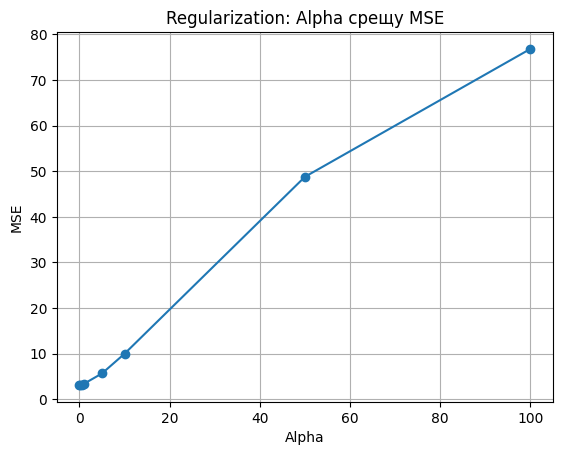

In [47]:
plt.plot(ridge_results_table["Alpha"], ridge_results_table["MSE"], marker="o")

plt.title("Regularization: Alpha срещу MSE")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.grid(True)

plt.show()

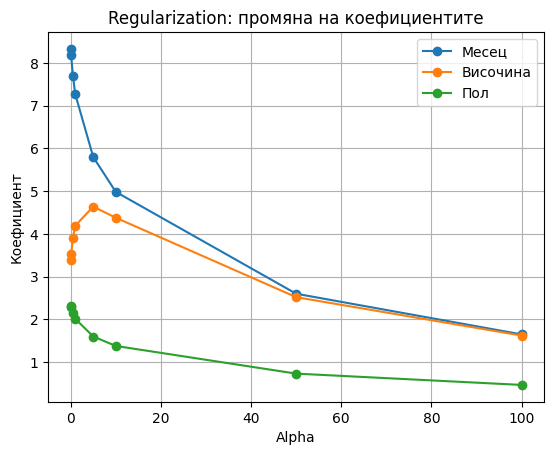

In [48]:
plt.plot(
    ridge_results_table["Alpha"],
    ridge_results_table["Месец коефициент"],
    marker="o",
    label="Месец"
)

plt.plot(
    ridge_results_table["Alpha"],
    ridge_results_table["Височина коефициент"],
    marker="o",
    label="Височина"
)

plt.plot(
    ridge_results_table["Alpha"],
    ridge_results_table["Пол коефициент"],
    marker="o",
    label="Пол"
)

plt.title("Regularization: промяна на коефициентите")
plt.xlabel("Alpha")
plt.ylabel("Коефициент")
plt.grid(True)
plt.legend()

plt.show()

## 8.2 Какво виждам от графиките?

Първата графика показва как се променя MSE при различна сила на regularization.

Втората графика показва как regularization влияе на коефициентите.

Когато alpha става по-голямо, моделът започва да ограничава коефициентите.

Това може да направи модела по-стабилен, но ако alpha е прекалено голямо, моделът може да стане прекалено слаб.

In [49]:
assert ridge_mse >= 0
assert len(ridge_prediction) == len(y_values)
assert len(ridge_results_table) == len(alpha_values)

print("Tests passed")
print("Regularization моделът работи.")
print("Ridge prediction е създадена правилно.")
print("MSE стойностите са валидни.")

Tests passed
Regularization моделът работи.
Ridge prediction е създадена правилно.
MSE стойностите са валидни.


# 9. Final Model Testing — финално сравнение на моделите

В тази част събирам всички модели, които направих в notebook-а, и ги сравнявам чрез MSE.

Целта ми е да видя:

- кой модел работи най-добре върху примерните Cane Corso данни
- как outliers влияят на regression
- кога polynomial regression може да помогне
- как multi-dimensional regression използва повече информация
- как regularization прави модела по-стабилен

Важно: това е учебна тестова проба, не реална ветеринарна оценка.

In [50]:
final_model_results = pd.DataFrame({
    "Модел": [
        "Мъжко тегло — simple linear regression",
        "Женско тегло — simple linear regression",
        "Мъжко тегло с шум — linear regression",
        "Женско тегло с шум — linear regression",
        "Outliers — ordinary regression",
        "Outliers — RANSAC-style regression",
        "Мъжко — polynomial regression degree 2",
        "Женско — polynomial regression degree 2",
        "Simple all-data model: месец → тегло",
        "Multi-dimensional: месец + височина + пол → тегло",
        "Ridge-style regularized regression"
    ],
    "MSE": [
        male_mse,
        female_mse,
        male_noisy_mse,
        female_noisy_mse,
        ordinary_outlier_mse,
        ransac_inlier_mse,
        male_poly_mse,
        female_poly_mse,
        simple_all_mse,
        multi_mse,
        ridge_mse
    ]
})

final_model_results = final_model_results.sort_values("MSE")

final_model_results

,Модел,MSE
1,Женско тегло — simple linear regression,1.958788
6,Мъжко — polynomial regression degree 2,2.309556
7,Женско — polynomial regression degree 2,2.459180
0,Мъжко тегло — simple linear regression,3.065455
9,Multi-dimensional: месец + височина + пол → тегло,3.124044
10,Ridge-style regularized regression,3.372587
3,Женско тегло с шум — linear regression,3.728668
5,Outliers — RANSAC-style regression,3.805146
2,Мъжко тегло с шум — linear regression,5.777341
8,Simple all-data model: месец → тегло,15.385500


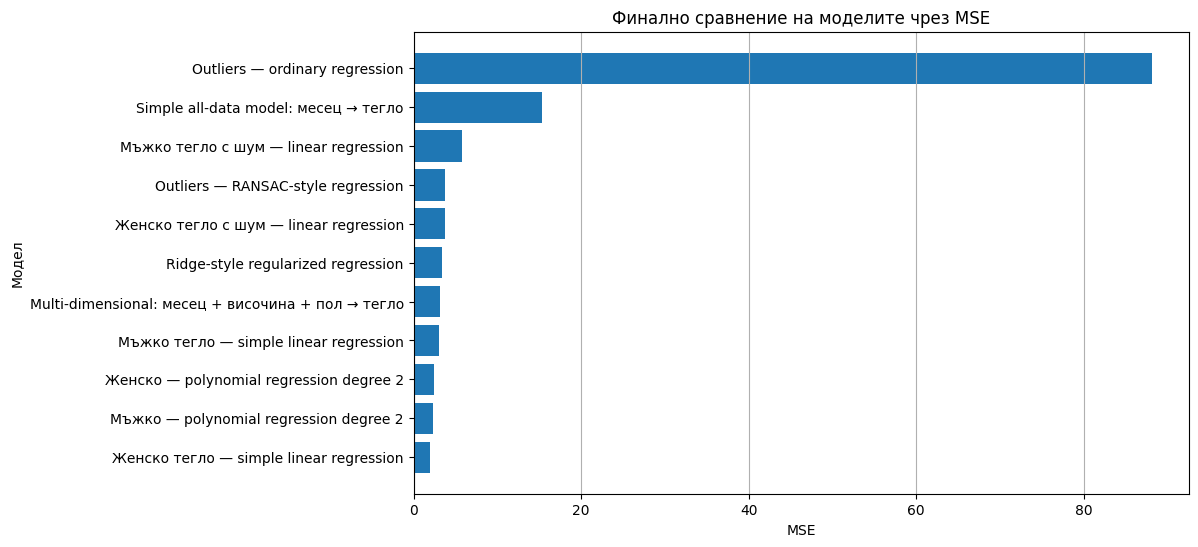

In [51]:
plt.figure(figsize=(10, 6))

plt.barh(final_model_results["Модел"], final_model_results["MSE"])

plt.title("Финално сравнение на моделите чрез MSE")
plt.xlabel("MSE")
plt.ylabel("Модел")
plt.grid(axis="x")

plt.show()

## 9.1 Какво показва финалното сравнение?

В тази таблица и графика виждам кои модели имат по-малка грешка.

По-малко MSE означава, че моделът пасва по-добре на конкретните примерни данни.

Но това не означава автоматично, че моделът е най-добър за реалния свят.

Например:

- polynomial regression може да има по-ниско MSE, но може да се нагоди прекалено много към малко данни
- RANSAC-style regression е полезна при outliers
- multi-dimensional regression използва повече информация
- regularization помага моделът да бъде по-стабилен

In [52]:
assert len(final_model_results) > 0
assert final_model_results["MSE"].isna().sum() == 0
assert (final_model_results["MSE"] >= 0).all()

assert male_a > 0
assert female_a > 0
assert male_noisy_a > 0
assert female_noisy_a > 0
assert ransac_a > 0

assert len(multi_prediction) == len(y)
assert len(ridge_prediction) == len(y_values)

print("Final tests passed")
print("Всички MSE стойности са валидни.")
print("Основните regression модели имат положителен наклон.")
print("Multi-dimensional и Ridge predictions са с правилна дължина.")

Final tests passed
Всички MSE стойности са валидни.
Основните regression модели имат положителен наклон.
Multi-dimensional и Ridge predictions са с правилна дължина.


# Финално обобщение — какво направих

В този notebook направих тестова проба за **Cane Corso Regression and Testing**.

Използвах примерни Cane Corso данни, за да разбера как различни regression техники могат да помагат при анализ на растеж, тегло и височина.

---

## 1. Започнах с основната идея на regression

Първо разгледах връзката:

`месец → тегло`

Идеята беше да видя дали теглото на Cane Corso може да се опише с математическа тенденция.

---

## 2. Направих Ordinary Least Squares regression

След това използвах linear regression, за да намеря права линия през примерните данни.

Моделът беше от типа:

`тегло = a * месец + b`

Така получих отделни regression линии за:

- мъжко Cane Corso
- женско Cane Corso

---

## 3. Използвах MSE за testing

След това изчислих MSE — Mean Squared Error.

MSE ми помогна да измеря колко греши моделът спрямо примерните данни.

Колкото по-малко е MSE, толкова по-добре моделът пасва на тези данни.

---

## 4. Добавих simulated data with noise

След това добавих шум към данните, за да направя примера по-реалистичен.

Реалните данни почти никога не са идеално подредени, защото има фактори като:

- хранене
- активност
- генетика
- различен темп на растеж
- грешки при измерване

Въпреки шума regression моделът пак успя да намери обща тенденция.

---

## 5. Направих RANSAC-style robust regression

След това добавих outliers — необичайни стойности.

Това показа, че обикновената regression линия може да се изкриви, ако има много странни или грешно въведени данни.

RANSAC-style подходът ми помогна да отделя нормалните точки от outliers и да намеря по-устойчива линия.

---

## 6. Направих Polynomial Regression

След това пробвах polynomial regression.

Това беше важно, защото растежът на куче не винаги е идеално права линия.

Polynomial regression позволява моделът да бъде крива, например:

`тегло = a * месец² + b * месец + c`

Това може да е полезно, когато растежът е по-бърз в началото и се забавя по-късно.

---

## 7. Направих Multi-dimensional Linear Regression

След това направих модел с повече входни данни:

`месец + височина + пол → тегло`

Това е по-близо до реален анализ, защото теглото не зависи само от възрастта.

То може да зависи и от:

- пол
- височина
- структура
- линия
- генетика
- хранене
- активност

---

## 8. Добавих Regularization

Накрая добавих Ridge-style regularization.

Regularization ми помогна да разбера как моделът може да стане по-стабилен, когато има повече характеристики.

Тя ограничава прекалено големите коефициенти и намалява риска моделът да се нагоди прекалено много към примерните данни.

---

## 9. Направих финално сравнение на моделите

В края събрах всички модели в една таблица и ги сравних чрез MSE.

Това ми даде общ поглед върху това как различните regression техники се държат върху примерните Cane Corso данни.

---

## Важно уточнение

Този notebook е учебна математическа проба.

Той не е ветеринарна диагноза и не е официална оценка на куче.

Regression моделът не казва дали едно куче е добро или лошо.

Той само показва:

- каква е тенденцията в данните
- каква стойност се очаква приблизително
- дали дадена стойност е близо или далеч от модела
- колко греши моделът според MSE

---

## Финален извод

С този notebook показах как regression може да се използва като помощен инструмент при Cane Corso анализ.

Моделът може да помага за:

1. проследяване на растеж
2. прогнозиране на тегло
3. сравнение между мъжко и женско
4. откриване на необичайни стойности
5. по-богат анализ с повече характеристики
6. basic model testing

Финалната логика е:

`данни → regression модел → графика → прогноза → MSE → testing`

Това може да бъде основа за бъдещ **Cane Corso Growth and Standard Assistant**.